## Project 1 — Customer's Behavior on E-commerce Platform 
**By Amanda Sim** 

## Part 0 — Finding and Choosing Your Dataset

I looked at GitHub and Kaggle for potential datasets. The first dataset I looked at was from GitHub, which analyzed user activity, such as how long they spend online and on social media. I graphed the dataset using scatter plots and found that they all collapsed into one blob, which was not ideal for computing k-Means and finding clustering. The second dataset I looked at was from Kaggle, and it was a Consumer Shopping Trends dataset. When I graph the dataset using scatter plots, they all showed up in straight lines, which again is not ideal for cluster and k-Means. The dataset I chose as my final dataset was the E-Commerce Customers Behavior dataset. This dataset met the requirements of having at least 4 numerical features, at least 100 rows, and real, meaningful features. Plus, when I graph the dataset on scatterplots, it showed up as clusters, which indicates that the dataset will be useful for clustering and producing k-Means. 


## Part 1 — Load, Inspect, and Clean

**Dataset: [E-commerce Customer Behavior Dataset](https://www.kaggle.com/datasets/uom190346a/e-commerce-customer-behavior-dataset) by Laksika Tharmalingam accessed via Kaggle**  

 * Each row represents an individual customer
 * Total rows: 450 -> 348 
     * removed missing values from Satisfaction Level 
 * Total columns: 11 -> 5
     * Removed non-numeric columns: Gender, City, Discount Applied, Satisfaction Level
     * Removed Customer ID - identifier not relevant for looking at customer behavior
     * Membership Type is a categorical label column


In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [4]:
url = 'E-commerce Customer Behavior - Sheet1.csv'  
df = pd.read_csv(url) 
df = df.drop(columns=["Customer ID"])

print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
 
#Inspect Column Names & Data Types
print("=" * 50)
print("COLUMN NAMES & DATA TYPES")
print("=" * 50)
print(df.info())
print()
 
#3. Check for Missing Values 
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
 
if missing_cols.empty:
    print("No missing values found.\n")
else:
    print(missing_cols)
    print()
 
# Handle Missing Values 
# Drop rows where 'Satisfaction Level' is missing (only 2 rows affected)
df = df.dropna(subset=["Satisfaction Level"])
print(f"Rows after dropping missing 'Satisfaction Level': {len(df)}\n")
 
# Extract Numerical Feature Columns into NumPy Matrix X
# Select all numeric columns, excluding 'Customer ID' (identifier, not a feature)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = ["Age", "Total Spend", "Items Purchased","Average Rating", "Days Since Last Purchase"]
 
X = df[feature_cols].to_numpy()
y = pd.Categorical(df['Membership Type']).codes
membership_type = pd.Categorical(df['Membership Type']).categories.tolist()
 
# Print Results
print("=" * 50)
print("NUMPY MATRIX X")
print("=" * 50)
print(f"Shape of X: {X.shape}\n")
 
print(f"Features used ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

df.head()

DATASET SHAPE
Rows: 350, Columns: 10

COLUMN NAMES & DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    350 non-null    object 
 1   Age                       350 non-null    int64  
 2   City                      350 non-null    object 
 3   Membership Type           350 non-null    object 
 4   Total Spend               350 non-null    float64
 5   Items Purchased           350 non-null    int64  
 6   Average Rating            350 non-null    float64
 7   Discount Applied          350 non-null    bool   
 8   Days Since Last Purchase  350 non-null    int64  
 9   Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(3), object(4)
memory usage: 25.1+ KB
None

MISSING VALUES
Satisfaction Level    2
dtype: int64

Rows after dropping missing 'Satisfactio

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


## Part 2 — Exploratory Data Analysis

### 2.1 Column Statistics

Compute the mean, standard deviation, and norm of each feature column and display the results in a formatted table. Write this code yourself — see Lectures 3 and 5 for the exact pattern.

Discuss what you observe. Are the features on similar scales, or do some dominate by orders of magnitude? This discussion should directly motivate what you do in Part 3.

In [5]:
summary = []

for col in feature_cols:
    mean = df[col].mean()
    std = df[col].std()
    norm = np.linalg.norm(df[col])
    
    summary.append([col, mean, std, norm])

# Convert to DataFrame
summary_table = pd.DataFrame(summary, columns=['Feature', 'Mean', 'Std Dev', 'Norm'])

summary_table = summary_table.round(4)

print("Statistics")
print("=" * 60)
print(summary_table)

Statistics
                    Feature      Mean   Std Dev        Norm
0                       Age   33.5776    4.8780    632.9384
1               Total Spend  847.7931  361.6924  17190.7275
2           Items Purchased   12.6322    4.1461    247.9839
3            Average Rating    4.0236    0.5791     75.8299
4  Days Since Last Purchase   26.6149   13.4747    556.3380




**Mean**
- Average Age is about 34 years old
- Average Total Spend is about $848
- Average Items Purchased is about 13 items
- Average Rating is about 4 out of 5
- Average Days Since Last Purchased is about 27 days

**Standard Deviation**
- Age, Items Purchased and Average Rating have relatively small standard deviation which indicates the values are closer to the mean
- Total Spend and Days Since Last Purchase have a slightly larger standard deviation which indicates there is more variability in these features and the values are more spread out from the mean 

**Norm**
- Total Spend - norm extremely large compared to the others - dominates others and will dominate when computing k-means cluster
- Average Rating - very small norm - will show minimal impact on clusters
- **Standardize all norms to evaluate all features equally**

### 2.2 Visualizations

### Scatterplots

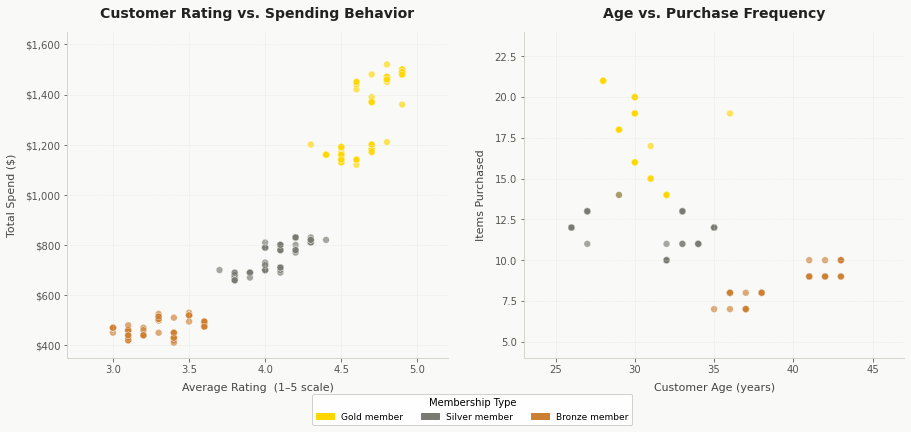

In [6]:
import matplotlib.patches as mpatches

# ── 2. Color Mapping (shared across both plots) ───────────────────────────────
membership_colors = {
    "Gold":   "#FFD700",
    "Silver": "#7A7A72",
    "Bronze": "#CD7F32",
}
 
def get_colors(series):
    return series.map(membership_colors)
 
# ── 3. Figure Setup ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("#F9F9F7")
 
for ax in (ax1, ax2):
    ax.set_facecolor("#F9F9F7")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCC4")
    ax.spines["bottom"].set_color("#CCCCC4")
    ax.tick_params(colors="#555550", labelsize=10)
    ax.grid(True, linestyle="--", linewidth=0.5, color="#DDDDDA", alpha=0.7)
 
# ── 4. Plot 1: Average Rating vs Total Spend ──────────────────────────────────
colors1 = get_colors(df["Membership Type"])
 
ax1.scatter(
    df["Average Rating"],
    df["Total Spend"],
    c=colors1,
    alpha=0.65,
    s=45,
    edgecolors="white",
    linewidths=0.4,
)
 
ax1.set_title(
    "Customer Rating vs. Spending Behavior",
    fontsize=14, fontweight="bold", color="#222220", pad=14
)
ax1.set_xlabel("Average Rating  (1–5 scale)", fontsize=11, color="#444440", labelpad=8)
ax1.set_ylabel("Total Spend ($)", fontsize=11, color="#444440", labelpad=8)
ax1.set_xlim(2.7, 5.2)
ax1.set_ylim(350, 1650)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
 
# ── 5. Plot 2: Age vs Items Purchased (K-Means ready clusters) ───────────────
colors2 = get_colors(df["Membership Type"])
 
ax2.scatter(
    df["Age"],
    df["Items Purchased"],
    c=colors2,
    alpha=0.65,
    s=45,
    edgecolors="white",
    linewidths=0.4,
)
 
ax2.set_title(
    "Age vs. Purchase Frequency",
    fontsize=14, fontweight="bold", color="#222220", pad=14
)
ax2.set_xlabel("Customer Age (years)", fontsize=11, color="#444440", labelpad=8)
ax2.set_ylabel("Items Purchased", fontsize=11, color="#444440", labelpad=8)
ax2.set_xlim(23, 47)
ax2.set_ylim(4, 24)
 
# ── 6. Shared Legend ─────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=membership_colors["Gold"],   label="Gold member"),
    mpatches.Patch(color=membership_colors["Silver"], label="Silver member"),
    mpatches.Patch(color=membership_colors["Bronze"], label="Bronze member"),
]
fig.legend(
    handles=legend_handles,
    title="Membership Type",
    title_fontsize=10,
    fontsize=9,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.04),
    frameon=True,
    framealpha=0.9,
    edgecolor="#CCCCCA",
)


**Scatterplot 1: Customer Rating vs Spending Behavior**
* Customers who rated their experience highly tend to spend more
    * Mostly Gold Members (highest membership)
* Customers who rated their experience lower tend to spend less
    * Mostly Bronze Members (lowest membership) 

**Scatterplot 2: Age vs Purchase Frequency**
* Customers from their mid-thirties to mid-forties tend to purchase less items
    * Most Bronze members fall under this 
* Customers in their mid-twenties to early-thirties tend to purchase more items
    * Mix between Gold and Silver members

### Histograms

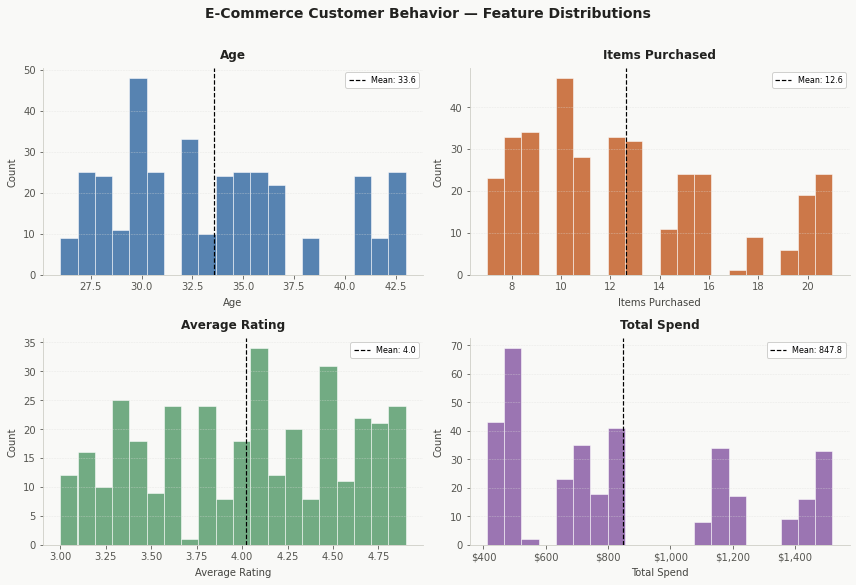

In [10]:
import matplotlib.ticker as mticker

numeric_cols = ['Age', 'Items Purchased', 'Average Rating', 'Total Spend']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.patch.set_facecolor("#F9F9F7")
axes = axes.flatten()
colors = ['#3A6EA5', '#C4612A', '#5A9E6F', '#8B5EA6']

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.set_facecolor("#F9F9F7")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#CCCCC4")
    ax.tick_params(colors="#555550", labelsize=10)
    ax.grid(True, linestyle="--", linewidth=0.5, color="#DDDDDA", alpha=0.6, axis='y')
    ax.hist(df[col], bins=20, color=colors[i], edgecolor='white',
            linewidth=0.6, alpha=0.85)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
    ax.set_title(col, fontsize=12, fontweight='bold', color='#222220', pad=10)
    ax.set_xlabel(col, fontsize=10, color='#444440', labelpad=6)
    ax.set_ylabel('Count', fontsize=10, color='#444440', labelpad=6)
    ax.legend(fontsize=8, framealpha=0.9, edgecolor='#CCCCCA')
    if col == 'Total Spend':
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))

fig.suptitle('E-Commerce Customer Behavior — Feature Distributions',
             fontsize=14, fontweight='bold', color='#222220', y=1.01)
plt.tight_layout()
plt.show()

**Age Histogram**
* Mostly younger demographic with the peak being age 30 
* Fairly even distribution around the mid-30s 
* Gaps in the data at around 31-32, 37.5 and 38-40

**Items Purchased Histogram**
* More people buy less items with a peak at 10 items
* Gaps at around 9, 11, 13, 16.5 and 18.5 items

**Average Rating Histogram**
* Slightly skewed to the left - higher average ratings 
* Bars are somewhat equal in height with an outlier at 3.75 rating
* Peak (most ratings) was at around 4.15  

**Total Spend Histogram**
* People either spend on the lower or higher end with most being at the lower end
* Most people spend around 500 dollars 
* Gaps at around 600, 850 to 1,050 and 1,250 to 1,350 dollars 

## Part 3 — Standardization

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X) 

n = X.shape[0] 
print(f"{'Feature':<22} {'Norm':>10}")
print('-' * 35)
for j, name in enumerate(feature_cols):
    print(f'{name:<22} {np.linalg.norm(X_std[:, j]):>10.4f}')

Feature                      Norm
-----------------------------------
Age                       18.6548
Total Spend               18.6548
Items Purchased           18.6548
Average Rating            18.6548
Days Since Last Purchase    18.6548


Standardization is necessary because we don’t want one feature to dominate the others. In this case, it would be Total Spending. Standardization ensures that all features contribute to the final k-Means results equally. 

## Part 4 — The k-Means Objective Function and Algorithm


### 4.1 The Objective Function

$$J^{\text{clust}} = \frac{1}{n} \sum_{i=1}^{n} \|\mathbf{x}_i - \mathbf{c}_{g_i}\|^2$$

$\mathbf{x}_i$ - the ith data point 

$\mathbf{c}_{g_i}$ - the centroid vector used to assign the data point to a cluster 

$\|\mathbf{x}_i - \mathbf{c}_{g_i}\|^2$ - measures the squared distance between the data point and the centroid

The algorithm is trying to get the data points to be as close to the centroid as possible. 


### 4.2 Lloyd's Algorithm 

1. Choose your K value and then intialize them to a centroid vector
2. Assign each data vector to the nearest centroid by finding the squared distance between the data vector and the centroid.
3. Update the centroids by finding the mean of all data vectors assigned to each group
4. Calculate your $J^{clust}$
5. Repeat steps 2-4 until $J^{clust}$ stops changing, this means $J^{clust}$ has converged

## Part 5 — k-Means with Scikit-learn

### 5.1 Choosing $k$: the Elbow Plot

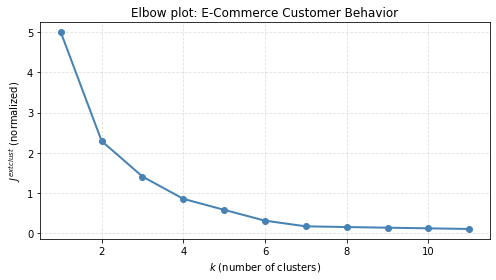

In [27]:
#Elbow plot
from sklearn.cluster import KMeans

J_values = []
k_values = range(1, 12)

for k_val in k_values:
    km = KMeans(n_clusters=k_val, n_init=10, random_state=0)
    km.fit(X_std)
    J_values.append(km.inertia_ / X_std.shape[0])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, J_values, marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('$k$ (number of clusters)')
ax.set_ylabel('$J^{\text{clust}}$ (normalized)')
ax.set_title('Elbow plot: E-Commerce Customer Behavior')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

The curve starts to flatten when k=3. Because of that, I chose k=3 for my k value, and also because there are three membership tiers we are evaluating, it makes sense to choose 3. 

### 5.2 Fitting the Final Model

In [28]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
labels = kmeans.fit_predict(X_std)

print('Cluster labels:', labels[:])
print('Cluster label counts:', np.bincount(labels))

# centroids
centers = kmeans.cluster_centers_
print('Cluster centroids (standardized):', np.round(centers, 4))


Cluster labels: [0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0
 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 0 2 1
 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0
 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 0 2 1 0 2 1
 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0
 2 1 0 2 1 0 2 1 0 2 1 0 2 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1
 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0
 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2
 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1
 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1]
Cluster label counts: [117 114 117]
Cluster centroids (standardized): [[-0.7503  1.2829  1.2036  1.1268 -0.6447]
 [ 1.196  -1.0343 -0.9938 -1.2057  0.3839]
 [-0.4151 -0.2751 -0.2353  0.0479  0.2706]]


The clusters are roughly balanced with 117, 114 and 117. This roughly balanced cluster indicates that this dataset is well-suited for clustering. 

## Part 6 — PCA and Visualization

### 6.1 Reduce to 2D

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
V = pca.fit_transform(X_std) 

print('V shape:', V.shape)
print(f'First 3 rows of V:')
print(np.round(V[:3, :], 4))

V shape: (348, 2)
First 3 rows of V:
[[ 1.4587  0.4197]
 [-0.0774 -0.6057]
 [-2.556  -0.0467]]


In [30]:
evr = pca.explained_variance_ratio_
print(f'PC1 explains {evr[0]*100:.1f}% of total variance')
print(f'PC2 explains {evr[1]*100:.1f}% of total variance')
print(f'Together:    {sum(evr)*100:.1f}%')

PC1 explains 74.3% of total variance
PC2 explains 17.2% of total variance
Together:    91.4%


The variance is high at 91.4%. This means that it was able to retain most of the information despite decreasing its dimensions to 2. The high variance means that the clusters are meaningful but not perfect.

### 6.2 Visualize

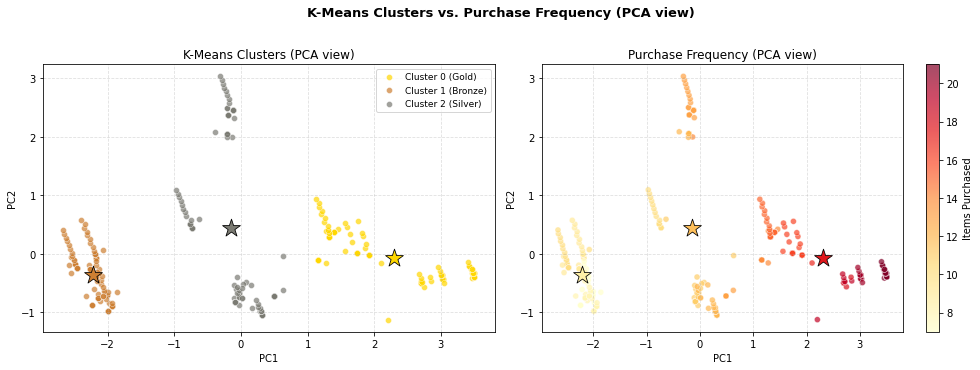

In [31]:
import matplotlib.cm as cm
import matplotlib.patches as mpatches

tier_by_code = {
    0: 'Bronze',
    1: 'Gold',
    2: 'Silver'
}
color_map = {}
for c in range(3):
    counts = [int(np.sum((labels == c) & (y == k))) for k in range(3)]
    color_map[c] = int(np.argmax(counts))
cat = pd.Categorical(df['Membership Type'])
tier_by_code = {i: name for i, name in enumerate(cat.categories)}
colors = ['#CD7F32', '#FFD700', '#7A7A72']  # Bronze=0, Gold=1, Silver=2
cluster_colors = [colors[color_map[c]] for c in range(3)]
centers_pca = pca.transform(centers)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left panel: K-Means Clusters ─────────────────────────────────────────────
for c in range(3):
    mask = (labels == c)
    matched_name = tier_by_code[color_map[c]]
    ax1.scatter(V[mask, 0], V[mask, 1], color=cluster_colors[c],
                label=f'Cluster {c} ({matched_name})', alpha=0.7,
                edgecolors='white', linewidth=0.5)
for c in range(3):
    ax1.scatter(centers_pca[c, 0], centers_pca[c, 1],
                color=cluster_colors[c], marker='*', s=350,
                edgecolors='black', linewidth=0.8, zorder=5)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('K-Means Clusters (PCA view)')
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# ── Right panel: Purchase Frequency ──────────────────────────────────────────
purchase_freq = df['Items Purchased'].values
norm = plt.Normalize(purchase_freq.min(), purchase_freq.max())
cmap = cm.YlOrRd

sc = ax2.scatter(V[:, 0], V[:, 1], c=purchase_freq, cmap=cmap, norm=norm,
                 alpha=0.7, edgecolors='white', linewidth=0.5)

# Centroid stars colored by their mean purchase frequency
for c in range(3):
    mask = (labels == c)
    mean_freq = purchase_freq[mask].mean()
    ax2.scatter(centers_pca[c, 0], centers_pca[c, 1],
                color=cmap(norm(mean_freq)), marker='*', s=350,
                edgecolors='black', linewidth=0.8, zorder=5)

cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label('Items Purchased', fontsize=10)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('Purchase Frequency (PCA view)')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('K-Means Clusters vs. Purchase Frequency (PCA view)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

* Clusters well seperated into three groups
* Strong positive correlation between Purchase Frequency and Membership tier
    * High purchasing frequency - Gold membership
    * Middle purchasing frequency - Silver membership
    * Low purchasing frequency - Bronze membership 

## Part 7 — Reflection

### Findings 
* Clusters are more spread out horizontally which I thought was interesting but also means that my PC1 captures most of the variance in my data being 74.3% 
* Those who interact more with the plaform based on the features - Gold membership (highest)
* Those who interact moderately with the platform based on the features - Silver membership (middle)
* Those who interact less with the platform based on the features - Bronze membership (lowest)
* There's a positive relationship between membership types and purchase frequency
* Silver membership has a more spread out cluster while Bronze membership is more compact 

### Positives 
* Dataset had high variance of 91.4%
* Clusters are roughly balanced at 117, 114, and 117
* Clusters are well separated into three groups 
* Clusters were meaningful and revealed the relationship between membership types and purchase frequency - those who purchase more frequently were Gold (highest) while those who purchase less frequently were Bronze (lowest) 

### Weaknesses 
* The dataset does not specify what e-commerce platform they looked at - dataset could be synthetic (unknown)


### What's next 
* Want to look at how satisfaction level impacts these membership statuses and customer's behavior
  - Using satisfaction level as the ground truth label 